# Real-Time Weather Data Extraction and Trend Analysis

This project extracts weather forecast data from the OpenWeather API and analyzes trends using Python.

## Import Libraries

In [17]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

## Extract Weather Data from API

In [4]:
API_KEY = "43d227f42b7029344926ba96f0a649b4"

city = "Delhi"

url = f"https://api.openweathermap.org/data/2.5/forecast?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)

data = response.json()

print("Status Code:", response.status_code)

Status Code: 200


## Convert API Response to DataFrame

In [8]:
weather_data = []

for item in data['list']:
    
    record = {
        "datetime": item["dt_txt"],
        "temperature": item["main"]["temp"],
        "humidity": item["main"]["humidity"],
        "pressure": item["main"]["pressure"],
        "wind_speed": item["wind"]["speed"]
    }
    
    weather_data.append(record)

df = pd.DataFrame(weather_data)

df.index = df.index + 1

df.head()
df.head()

,datetime,temperature,humidity,pressure,wind_speed
1,2026-03-10 21:00:00,25.65,14,1013,1.74
2,2026-03-11 00:00:00,25.10,15,1013,1.26
3,2026-03-11 03:00:00,26.17,15,1014,0.86
4,2026-03-11 06:00:00,33.58,9,1014,2.70
5,2026-03-11 09:00:00,37.29,7,1009,4.46


## Data Cleaning

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

df = df.sort_values(by="datetime")

df = df.drop_duplicates()

df.reset_index(drop=True, inplace=True)

# Start index from 1
df.index = df.index + 1
df.index.name = "Record"

df

,datetime,temperature,humidity,pressure,wind_speed
Record,,,,,
1,2026-03-10 21:00:00,25.65,14,1013,1.74
2,2026-03-11 00:00:00,25.10,15,1013,1.26
3,2026-03-11 03:00:00,26.17,15,1014,0.86
4,2026-03-11 06:00:00,33.58,9,1014,2.70
5,2026-03-11 09:00:00,37.29,7,1009,4.46
6,2026-03-11 12:00:00,35.36,9,1007,4.67
7,2026-03-11 15:00:00,31.74,10,1009,3.19
8,2026-03-11 18:00:00,28.87,9,1009,2.63
9,2026-03-11 21:00:00,27.20,12,1008,3.45


## Exploratory Data Analysis

In [11]:
df.describe().round(2)

,datetime,temperature,humidity,pressure,wind_speed
count,40,40.00,40.00,40.00,40.00
mean,2026-03-13 07:30:00,30.81,11.58,1006.48,2.56
min,2026-03-10 21:00:00,24.76,5.00,1001.00,0.11
25%,2026-03-12 02:15:00,27.16,9.00,1004.75,1.78
50%,2026-03-13 07:30:00,30.52,11.50,1006.00,2.52
75%,2026-03-14 12:45:00,35.13,14.00,1008.00,3.17
max,2026-03-15 18:00:00,37.34,22.00,1014.00,5.49
std,NaN,4.24,3.51,3.16,1.11


## Temperature Trend

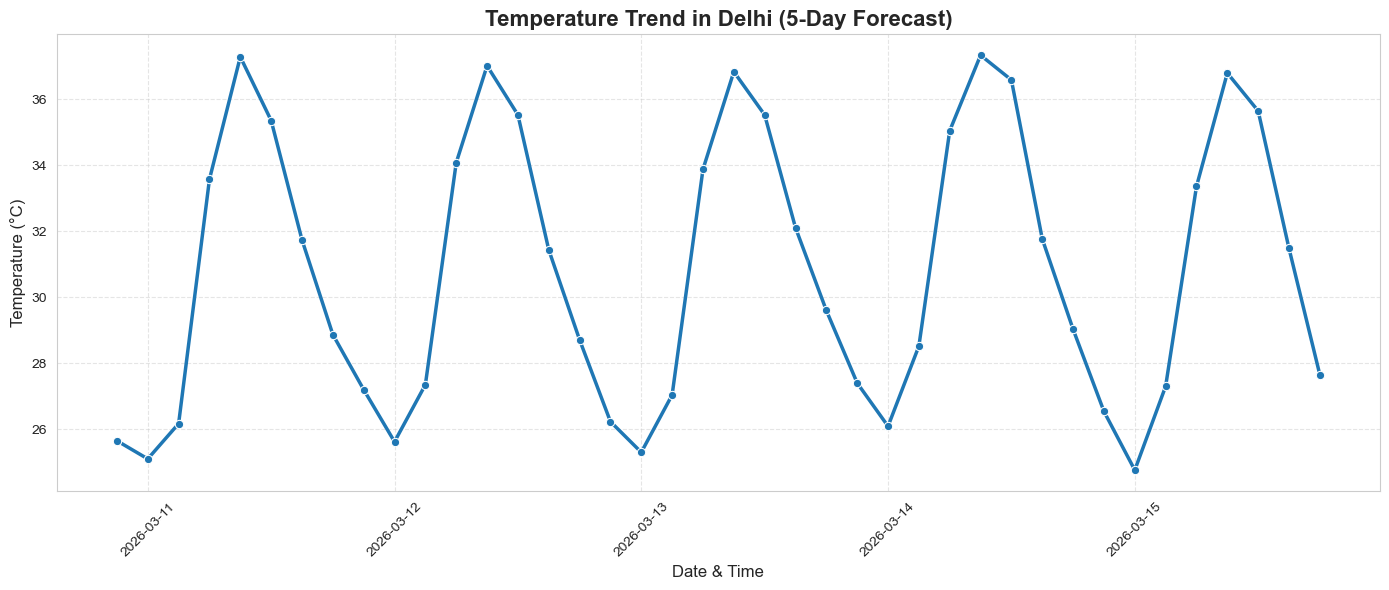

In [13]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x=df['datetime'],
    y=df['temperature'],
    marker='o',
    linewidth=2.5,
    color='#1f77b4'
)

plt.title("Temperature Trend in Delhi (5-Day Forecast)", fontsize=16, fontweight='bold')

plt.xlabel("Date & Time", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

## Humidity Trend

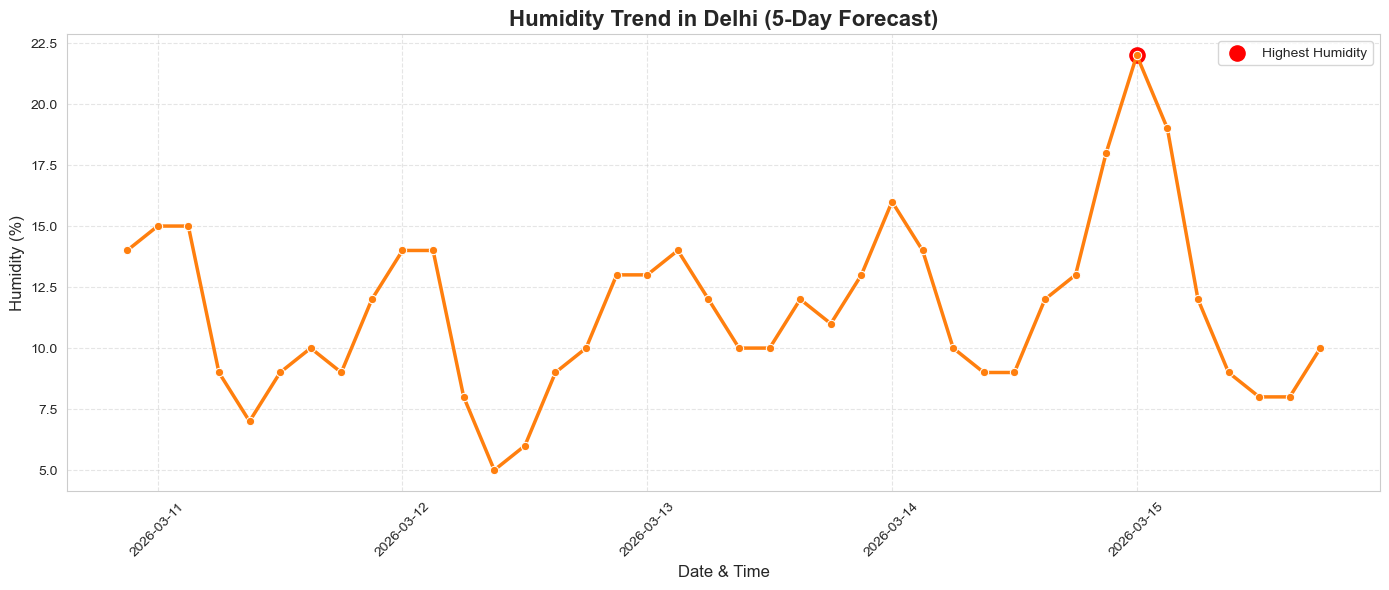

In [14]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x=df['datetime'],
    y=df['humidity'],
    marker='o',
    linewidth=2.5,
    color='#ff7f0e'
)

plt.title("Humidity Trend in Delhi (5-Day Forecast)", fontsize=16, fontweight='bold')

plt.xlabel("Date & Time", fontsize=12)
plt.ylabel("Humidity (%)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

# Highlight maximum humidity
max_humidity = df['humidity'].max()
max_row = df[df['humidity'] == max_humidity]

plt.scatter(max_row['datetime'], max_row['humidity'],
            color='red', s=120, label='Highest Humidity')

plt.legend()

plt.tight_layout()

plt.show()

## Wind Speed Trend

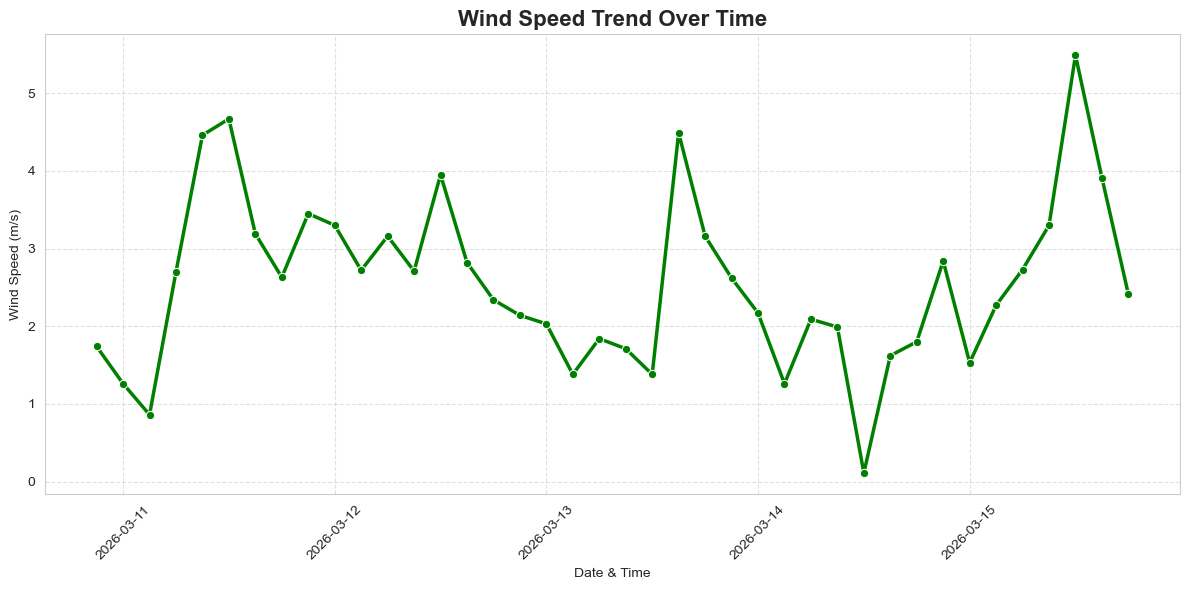

In [21]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='datetime',
    y='wind_speed',
    marker='o',
    linewidth=2.5,
    color='green'
)

plt.title("Wind Speed Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date & Time")
plt.ylabel("Wind Speed (m/s)")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

## Correlation Analysis


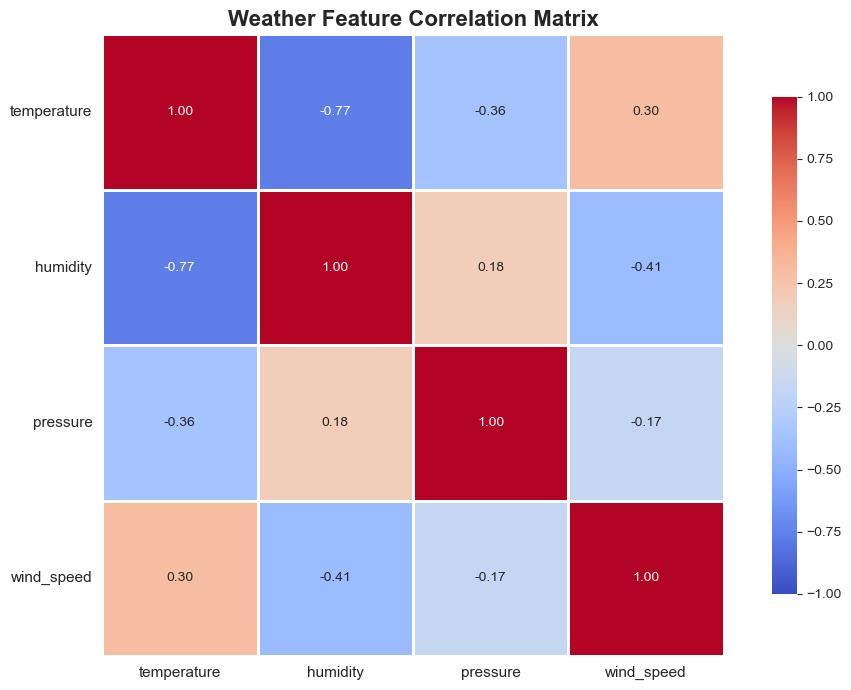

In [22]:
plt.figure(figsize=(10,7))

corr = df[['temperature','humidity','pressure','wind_speed']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Weather Feature Correlation Matrix", fontsize=16, fontweight="bold")

plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.show()

## Save Dataset

In [23]:
df.to_csv("delhi_weather_forecast.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


## Conclusion

Weather data was extracted from an API, processed using Python, and visualized to identify trends in temperature and humidity.